# 📌 Extracción

## Importar los datos

In [1]:
import requests
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
respuesta = requests.get(url)
diccionario = respuesta.json()
datos = pd.DataFrame(diccionario)
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
datos = pd.json_normalize(diccionario)
datos.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## Metadatos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

# 🔧 Transformación

## Conocer el conjunto de datos

In [4]:
datos.head(1)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3


In [5]:
# Ver información relevante de los datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

## Comprobar incoherencias en los datos

In [6]:
# Virificar los valores únicos en cada columna
for columna in datos.columns:

  cantidad_unicos = datos[columna].nunique()
  print(f'{columna}: {cantidad_unicos}')

  if cantidad_unicos < 30:
    valores_unicos = datos[columna].unique()
    print(valores_unicos)
  print('-' * 80)

customerID: 7267
--------------------------------------------------------------------------------
Churn: 3
['No' 'Yes' '']
--------------------------------------------------------------------------------
customer.gender: 2
['Female' 'Male']
--------------------------------------------------------------------------------
customer.SeniorCitizen: 2
[0 1]
--------------------------------------------------------------------------------
customer.Partner: 2
['Yes' 'No']
--------------------------------------------------------------------------------
customer.Dependents: 2
['Yes' 'No']
--------------------------------------------------------------------------------
customer.tenure: 73
--------------------------------------------------------------------------------
phone.PhoneService: 2
['Yes' 'No']
--------------------------------------------------------------------------------
phone.MultipleLines: 3
['No' 'Yes' 'No phone service']
--------------------------------------------------------------

## Manejar las inconsistencias

Acciones a realizar:

1. Transformar el tipo de dato de la columna `account.Charges.Total` a float.
2. Eliminar registros con valores vacíos de la columna `Churn`.
3. Verificar la existencia de valores nulos.
4. Verificar la existencia de registros duplicados.

1. Transformar el tipo de dato de la columna `account.Charges.Total` a float.

In [7]:
# Convertir datos a numéricos
datos['account.Charges.Total'] = pd.to_numeric(datos['account.Charges.Total'], errors='coerce')

# Verificar el nuevo tipo de dato de la columna
datos['account.Charges.Total'].dtype

dtype('float64')

2. Eliminar registros con valores vacíos de la columna `Churn`.

In [8]:
# Cantidad de registros con valores vacíos
vacios = len(datos[datos['Churn'] == ''])
vacios

224

In [9]:
# Porcentaje de registros con valores vacíos
porcentaje_vacios = vacios * 100 / datos['Churn'].shape[0]
print(f'{round(porcentaje_vacios, 2)}%')

3.08%


In [10]:
# Ya que el porcentaje de registros con valores vacíos es bajo (menor al 5%)
# y considerando que no se tiene información adicional acerca del estado de evasión de esos clientes
# se eliminarán esos registros del conjunto de datos
datos = datos[datos['Churn'] != '']

# Cantidad de registros luego de la eliminación
datos.shape[0]

7043

3. Verificar la existencia de valores nulos.

In [11]:
# Revisar la cantidad de valores nulos de cada columna
datos.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [12]:
# Porcentaje de datos nulos
porcentaje_nulos = datos['account.Charges.Total'].isnull().sum() * 100 / datos['account.Charges.Total'].shape[0]
print(f'{round(porcentaje_nulos, 2)}%')

0.16%


In [13]:
# Ya que el porcentaje de datos nulos es muy bajo (menor al 5%)
# y considerando que no se tiene información adicional acerca del pago total de esos clientes
# sumado a que son datos que se derivan de diversas otras columnas
# se eliminarán esos registros del conjunto de datos
datos = datos.dropna(subset=['account.Charges.Total']).reset_index(drop=True)

# Revisar la cantidad de valores nulos después de la eliminación
datos.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


4. Verificar la existencia de registros duplicados.

In [14]:
# Revisar la cantidad de registros duplicados
print(datos.duplicated().sum())

0


## Estandarizar y transformar los datos

Acciones a realizar:

1. Crear la columna `account.Charges.Daily`.
2. Transformar la columna `customer.SeniorCitizen` a categórica (Yes/No).
3. Renombrar todas las columnas.
4. Crear la columna `total_services`.


1. Crear la columna `account.Charges.Daily`.

In [15]:
# Crear la columna
datos['account.Charges.Daily'] = datos['account.Charges.Monthly'] / 30
datos.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,account.Charges.Daily
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


2. Transformar la columna `customer.SeniorCitizen` a categórica (Yes/No).

In [16]:
# Transformar la columna
datos['customer.SeniorCitizen'] = datos['customer.SeniorCitizen'].replace({1: 'Yes', 0: 'No'})

# Virificar el nuevo tipo de dato y los valores únicos de la columna
datos['customer.SeniorCitizen'].unique()

array(['No', 'Yes'], dtype=object)

3. Renombrar todas las columnas.

In [17]:
# Nombres de columnas actuales
list(datos.columns)

['customerID',
 'Churn',
 'customer.gender',
 'customer.SeniorCitizen',
 'customer.Partner',
 'customer.Dependents',
 'customer.tenure',
 'phone.PhoneService',
 'phone.MultipleLines',
 'internet.InternetService',
 'internet.OnlineSecurity',
 'internet.OnlineBackup',
 'internet.DeviceProtection',
 'internet.TechSupport',
 'internet.StreamingTV',
 'internet.StreamingMovies',
 'account.Contract',
 'account.PaperlessBilling',
 'account.PaymentMethod',
 'account.Charges.Monthly',
 'account.Charges.Total',
 'account.Charges.Daily']

In [18]:
# Número de columnas actuales
len(datos.columns)

22

In [19]:
# Renombrar las columnas
nombres_columnas = ['customer_id', 'churn',
                    'gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
                    'phone_service', 'multiple_lines',
                    'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
                    'contract', 'paperless_billing', 'payment_method', 'charges_monthly', 'charges_total', 'charges_daily']

datos.columns = nombres_columnas

In [20]:
# Verificar cambios de nombres de columnas
list(datos.columns)

['customer_id',
 'churn',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'charges_monthly',
 'charges_total',
 'charges_daily']

In [21]:
# Verificar la consistencia en el número de columnas
len(datos.columns)

22

4. Crear la columna `total_services`.

In [22]:
# Crear columna de servicios contratados
servicios = ['phone_service', 'multiple_lines',
             'online_security', 'online_backup', 'device_protection',
             'tech_support', 'streaming_tv', 'streaming_movies']

datos['total_services'] = (datos[servicios] == 'Yes').sum(axis=1) + (datos['internet_service'] != 'No')

# Virificar el nuevo tipo de dato y los valores únicos de la columna
print(datos['total_services'].dtype)
datos['total_services'].unique()

int64


array([5, 4, 3, 6, 8, 9, 2, 7, 1])

In [23]:
# Inspeccionar el conjunto de datos
datos.sample(5)

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,charges_monthly,charges_total,charges_daily,total_services
4055,5730-RIITO,No,Female,Yes,No,No,43,No,No phone service,DSL,...,No,No,No,Month-to-month,Yes,Credit card (automatic),33.45,1500.25,1.115000,3
5729,8076-FEZKJ,No,Male,No,No,No,10,Yes,No,No,...,No internet service,No internet service,No internet service,One year,No,Mailed check,19.50,225.85,0.650000,1
2595,3716-BDVDB,Yes,Male,No,No,No,1,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,69.10,69.10,2.303333,2
2169,3106-ULWFW,Yes,Female,No,Yes,No,8,Yes,Yes,Fiber optic,...,No,No,Yes,Month-to-month,Yes,Credit card (automatic),85.20,627.40,2.840000,4
450,0661-WCQNQ,No,Male,No,Yes,No,22,Yes,No,DSL,...,Yes,No,No,One year,Yes,Credit card (automatic),56.25,1292.20,1.875000,4


In [24]:
# Revisar la información actualizada de los datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7032 non-null   object 
 1   churn              7032 non-null   object 
 2   gender             7032 non-null   object 
 3   senior_citizen     7032 non-null   object 
 4   partner            7032 non-null   object 
 5   dependents         7032 non-null   object 
 6   tenure             7032 non-null   int64  
 7   phone_service      7032 non-null   object 
 8   multiple_lines     7032 non-null   object 
 9   internet_service   7032 non-null   object 
 10  online_security    7032 non-null   object 
 11  online_backup      7032 non-null   object 
 12  device_protection  7032 non-null   object 
 13  tech_support       7032 non-null   object 
 14  streaming_tv       7032 non-null   object 
 15  streaming_movies   7032 non-null   object 
 16  contract           7032 

# 📊 Carga y análisis

## Análisis descriptivo

In [25]:
# Variables cuantitativas
datos.describe()

,tenure,charges_monthly,charges_total,charges_daily,total_services
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,2.159940,4.147184
std,24.545260,30.085974,2266.771362,1.002866,2.312294
min,1.000000,18.250000,18.800000,0.608333,1.000000
25%,9.000000,35.587500,401.450000,1.186250,2.000000
50%,29.000000,70.350000,1397.475000,2.345000,4.000000
75%,55.000000,89.862500,3794.737500,2.995417,6.000000
max,72.000000,118.750000,8684.800000,3.958333,9.000000


In [26]:
# Variables categóricas
datos.describe(include=['object'])

,customer_id,churn,gender,senior_citizen,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,9995-HOTOH,No,Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,5163,3549,5890,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365


## Distribución de evasión

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

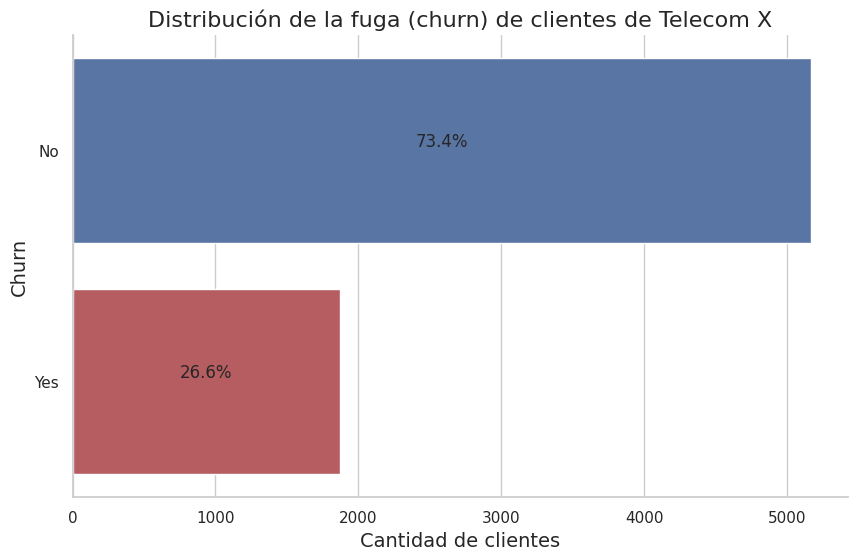

In [28]:
# Configurar estilo de gráficos
sns.set_theme(style='whitegrid')
sns.set_palette(['#4C72B0', '#C44E52'])

# Crear gráfico de distribución de la columna 'churn'
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.countplot(data=datos, y='churn', hue='churn')

ax.set_title('Distribución de la fuga (churn) de clientes de Telecom X', fontsize=16)
ax.set_xlabel('Cantidad de clientes', fontsize=14)
ax.set_ylabel('Churn', fontsize=14)

# Agragar porcentajes a barras
contador_churn = datos['churn'].value_counts()
porcentaje_churn = contador_churn * 100 / len(datos)
for i, porcentaje_churn in enumerate(porcentaje_churn):
  ax.text(contador_churn.iloc[i]/2, i, f'{porcentaje_churn:.1f}%', ha='center', va='bottom')

sns.despine()
plt.show()

## Recuento de evasión por variables categóricas

In [29]:
datos.columns

Index(['customer_id', 'churn', 'gender', 'senior_citizen', 'partner',
       'dependents', 'tenure', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method', 'charges_monthly',
       'charges_total', 'charges_daily', 'total_services'],
      dtype='object')

Se analizará la distribución de la variable `churn` de acuerdo con las variables:

* Género (`gender`).
* Tercera edad (`senior_citizen`).
* Tiene pareja (`partner`).
* Tiene dependientes (`dependents`).
* Servicio telefónico (`phone_service`).
* Múltiples líneas telefónicas (`multiple_lines`).
* Servicio de internet (`internet_service`).
* Seguridad online (`online_security`).
* Backup online (`online_backup`).
* Protección de dispositivo (`device_protection`).
* Soporte técnico (`tech_support`).
* Streaming de TV (`streaming_tv`).
* Streaming de películas (`streaming_movies`).
* Tipo de contrato (`contract`).
* Boleta digital (`paperless_billing`).
* Método de pago (`payment_method`).

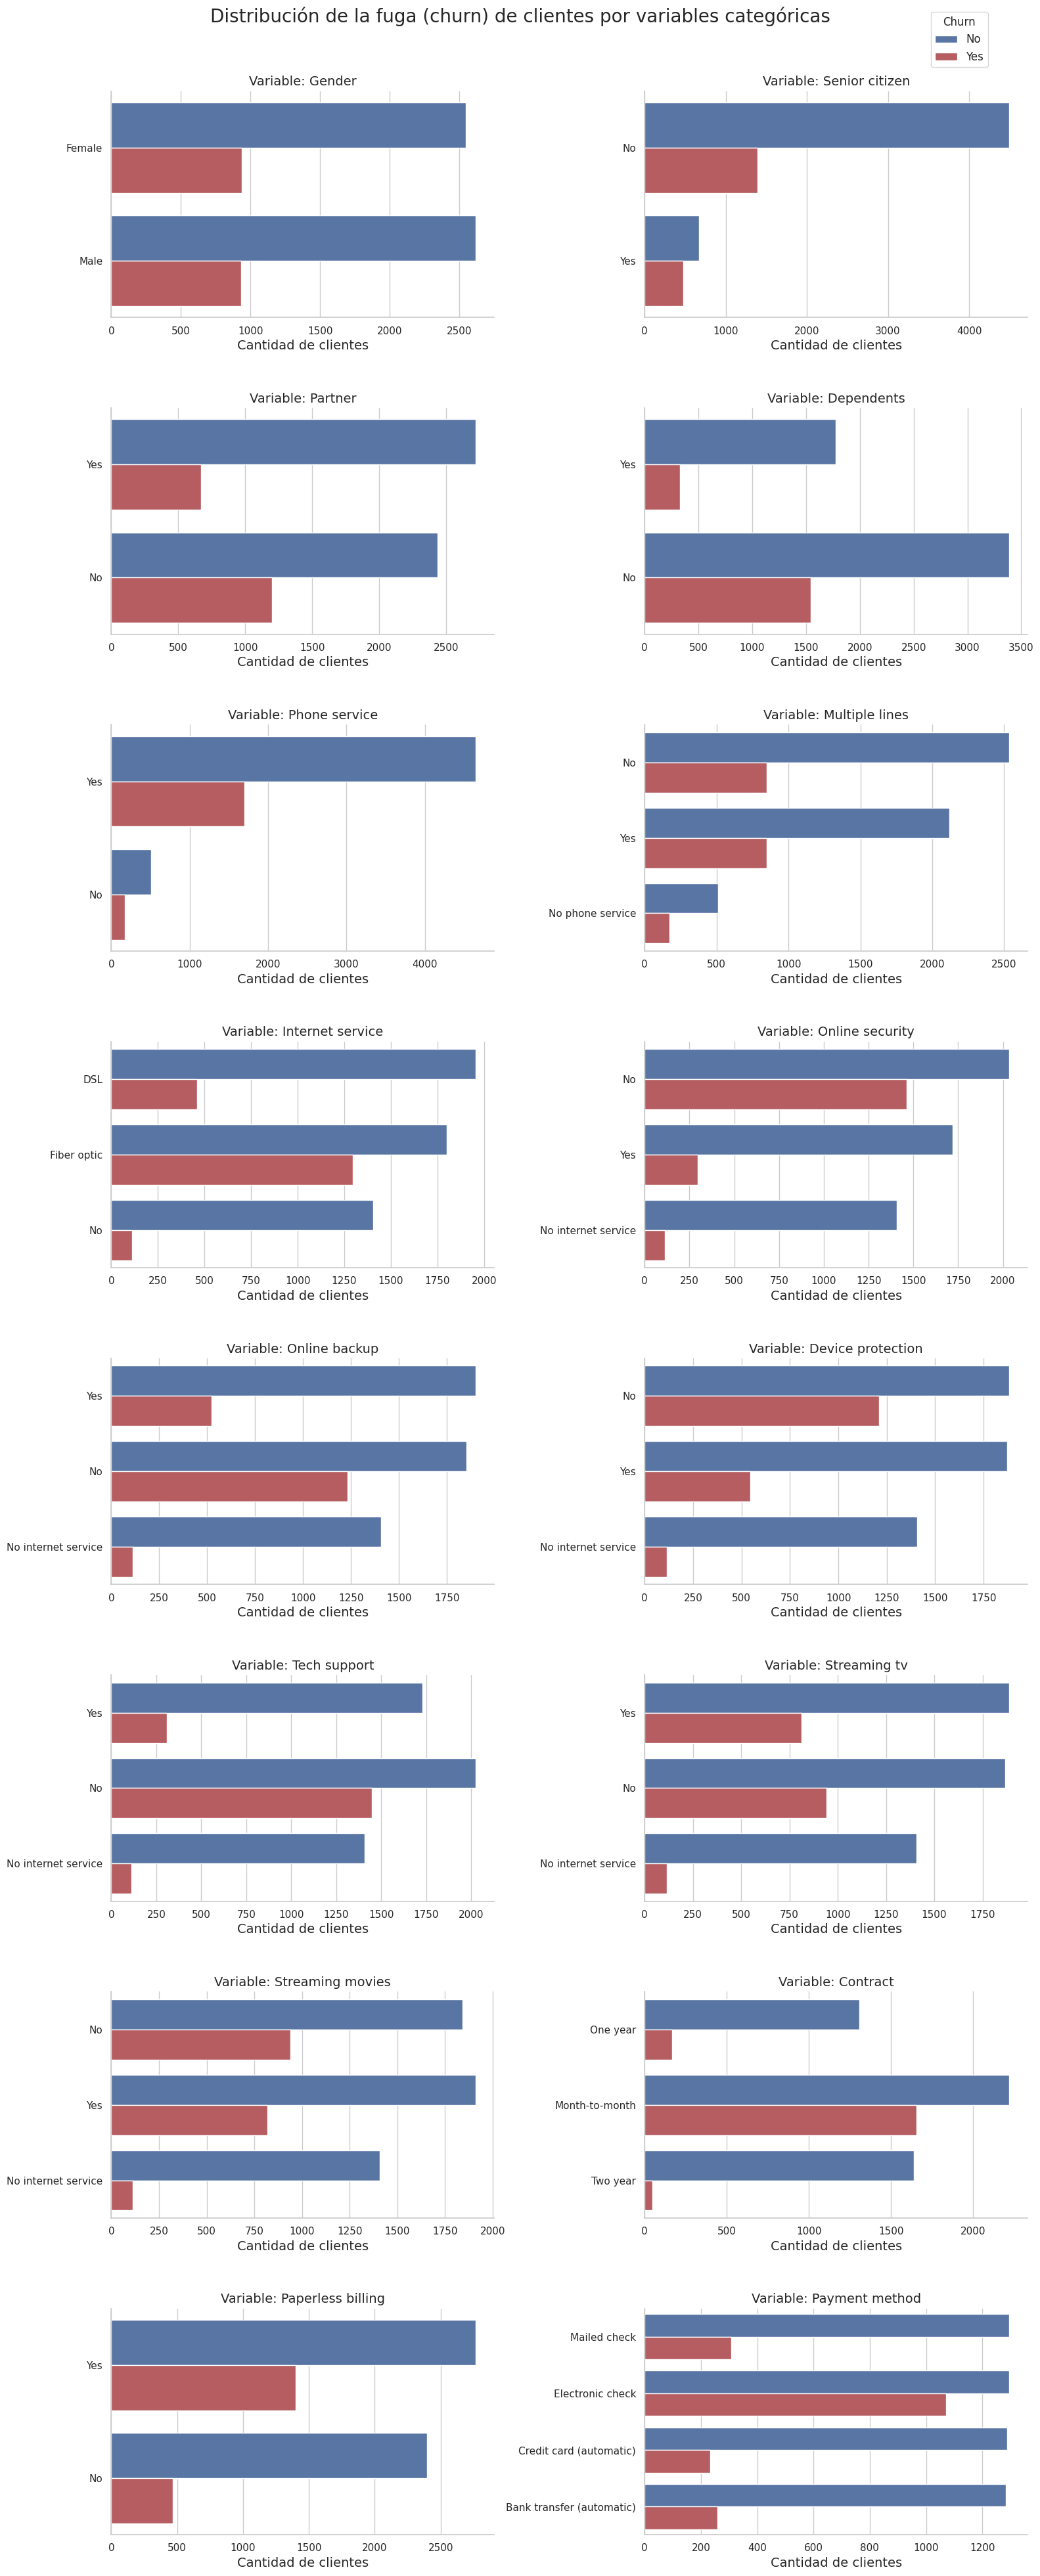

In [30]:
# Variables categóricas
variables_categoricas = ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines',
                         'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support',
                         'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']

# Crear gráfico de distribución de la columna 'churn' de clientes por método de pago
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(16, 40))
fig.suptitle('Distribución de la fuga (churn) de clientes por variables categóricas', fontsize=20)

axes = axes.flatten()

for i, variable in enumerate(variables_categoricas):
  ax = axes[i]
  sns.countplot(data=datos, y=variable, hue='churn', ax=ax)
  ax.set_title(f'Variable: {variable.replace('_', ' ').capitalize()}', fontsize=14)
  ax.set_xlabel('Cantidad de clientes', fontsize=14)
  ax.set_ylabel('')
  ax.get_legend().remove()
  sns.despine()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title='Churn',
           bbox_to_anchor=(0.95, 0.98), fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.subplots_adjust(hspace=0.4)
plt.show()

## Conteo de evasión por variables numéricas

Se analizará la distribución de la variable `churn` de acuerdo con las variables:

* Meses de contrato (`tenure`).
* Cargo mensual (`charges_monthly`).
* Cargo total (`charges_total`).
* Servicios contratados (`total_services`).

Variable `tenure`.

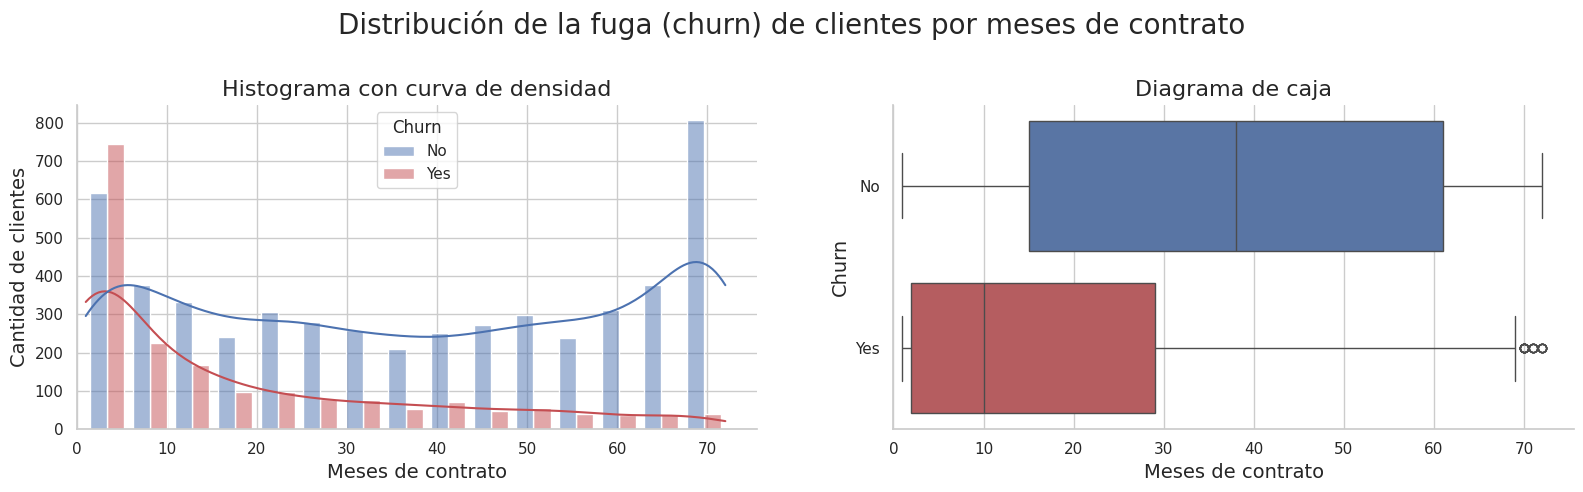

In [31]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribución de la fuga (churn) de clientes por meses de contrato', fontsize=20)

# Crear gráfico de distribución de la columna 'churn' de clientes por meses de contrato
sns.histplot(data=datos, x='tenure', hue='churn', kde=True, multiple='dodge', shrink=0.8, ax=axes[0])

axes[0].set_title('Histograma con curva de densidad', fontsize=16)
axes[0].set_xlabel('Meses de contrato', fontsize=14)
axes[0].set_ylabel('Cantidad de clientes', fontsize=14)
axes[0].get_legend().set_title('Churn')
axes[0].set_xlim(0)

# Crear diagrama de caja de la columna 'churn' de clientes por meses de contrato
sns.boxplot(data=datos, x='tenure', y='churn', hue='churn', ax=axes[1])

axes[1].set_title('Diagrama de caja', fontsize=16)
axes[1].set_xlabel('Meses de contrato', fontsize=14)
axes[1].set_ylabel('Churn', fontsize=14)
axes[1].set_xlim(0)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.subplots_adjust(wspace=0.2)
plt.show()

Variable `charges_monthly`.

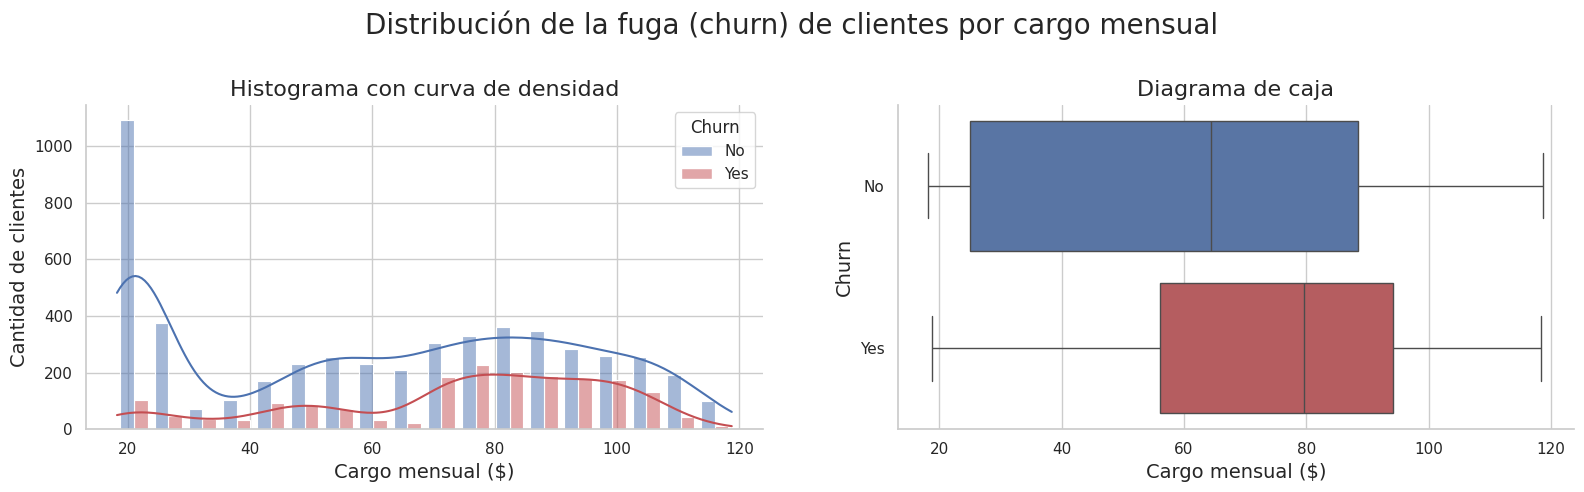

In [32]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribución de la fuga (churn) de clientes por cargo mensual', fontsize=20)

# Crear gráfico de distribución de la columna 'churn' de clientes por cargo mensual
sns.histplot(data=datos, x='charges_monthly', hue='churn', kde=True, multiple='dodge', shrink=0.8, ax=axes[0])

axes[0].set_title('Histograma con curva de densidad', fontsize=16)
axes[0].set_xlabel('Cargo mensual ($)', fontsize=14)
axes[0].set_ylabel('Cantidad de clientes', fontsize=14)
axes[0].get_legend().set_title('Churn')

# Crear diagrama de caja de la columna 'churn' de clientes por cargo mensual
sns.boxplot(data=datos, x='charges_monthly', y='churn', hue='churn', ax=axes[1])

axes[1].set_title('Diagrama de caja', fontsize=16)
axes[1].set_xlabel('Cargo mensual ($)', fontsize=14)
axes[1].set_ylabel('Churn', fontsize=14)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.subplots_adjust(wspace=0.2)
plt.show()

Variable `charges_total`.

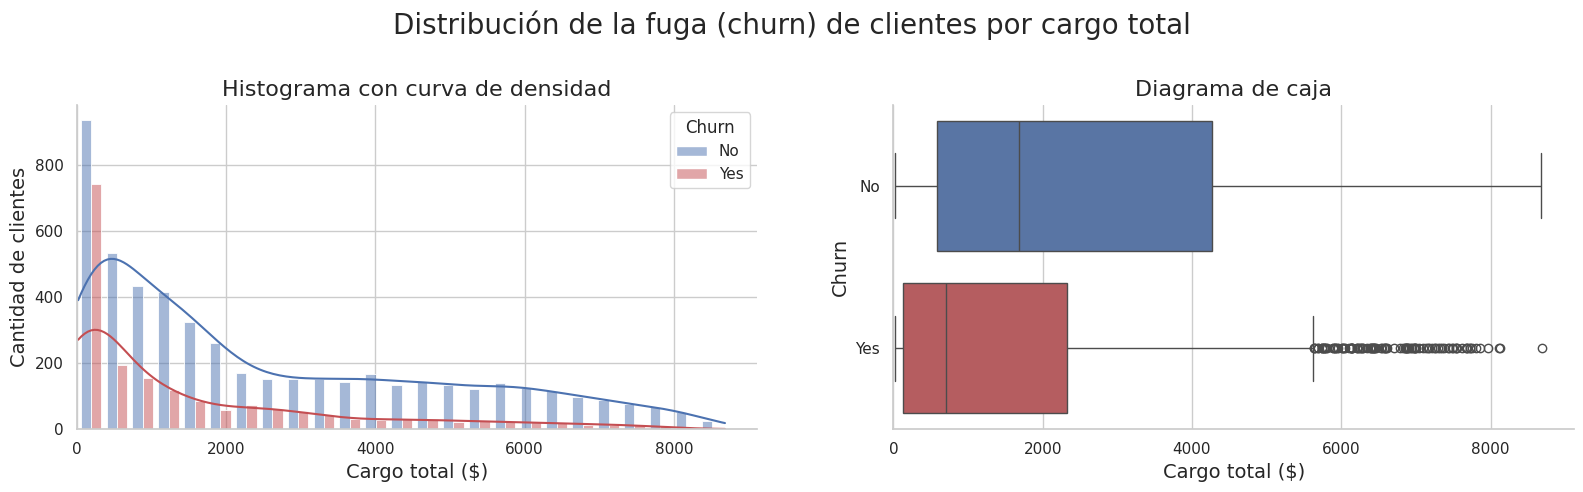

In [33]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribución de la fuga (churn) de clientes por cargo total', fontsize=20)

# Crear gráfico de distribución de la columna 'churn' de clientes por cargo total
sns.histplot(data=datos, x='charges_total', hue='churn', kde=True, multiple='dodge', shrink=0.8, ax=axes[0])

axes[0].set_title('Histograma con curva de densidad', fontsize=16)
axes[0].set_xlabel('Cargo total ($)', fontsize=14)
axes[0].set_ylabel('Cantidad de clientes', fontsize=14)
axes[0].get_legend().set_title('Churn')
axes[0].set_xlim(0)

# Crear diagrama de caja de la columna 'churn' de clientes por cargo total
sns.boxplot(data=datos, x='charges_total', y='churn', hue='churn', ax=axes[1])

axes[1].set_title('Diagrama de caja', fontsize=16)
axes[1].set_xlabel('Cargo total ($)', fontsize=14)
axes[1].set_ylabel('Churn', fontsize=14)
axes[1].set_xlim(0)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.subplots_adjust(wspace=0.2)
plt.show()

Variable `total_services`.

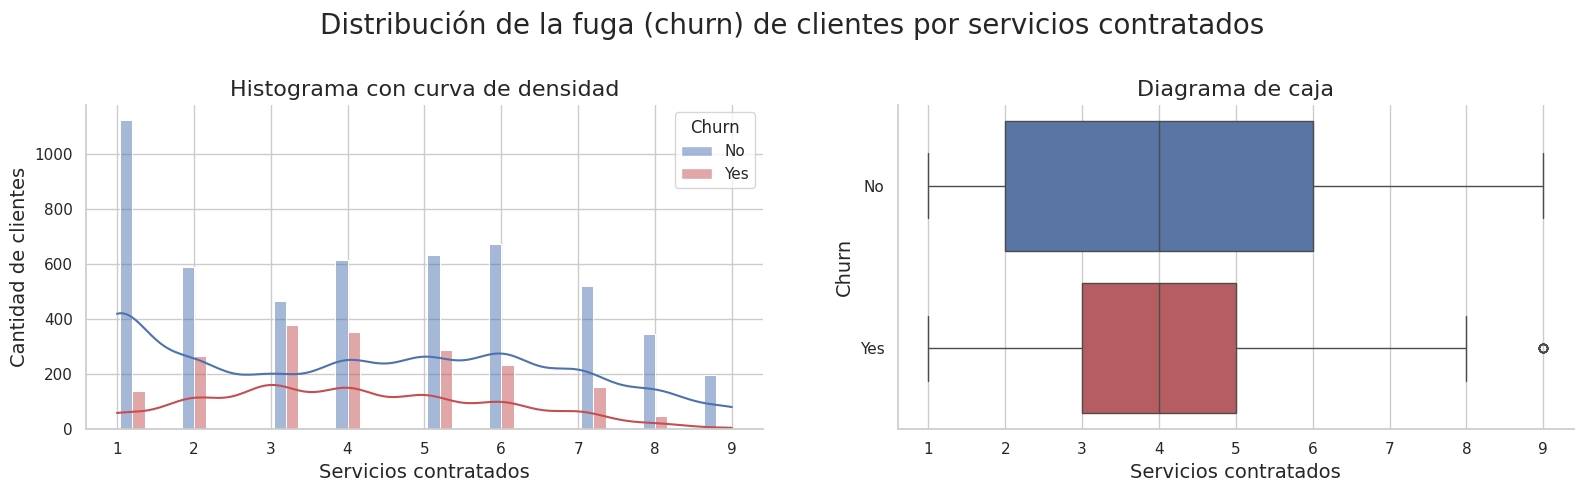

In [34]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Distribución de la fuga (churn) de clientes por servicios contratados', fontsize=20)

# Crear gráfico de distribución de la columna 'churn' de clientes por servicios contratados
sns.histplot(data=datos, x='total_services', hue='churn', kde=True, multiple='dodge', shrink=0.8, ax=axes[0])

axes[0].set_title('Histograma con curva de densidad', fontsize=16)
axes[0].set_xlabel('Servicios contratados', fontsize=14)
axes[0].set_ylabel('Cantidad de clientes', fontsize=14)
axes[0].get_legend().set_title('Churn')

# Crear diagrama de caja de la columna 'churn' de clientes por servicios contratados
sns.boxplot(data=datos, x='total_services', y='churn', hue='churn', ax=axes[1])

axes[1].set_title('Diagrama de caja', fontsize=16)
axes[1].set_xlabel('Servicios contratados', fontsize=14)
axes[1].set_ylabel('Churn', fontsize=14)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.subplots_adjust(wspace=0.2)
plt.show()

## Análisis de correlación entre variables

Se analizará la correlación de la variable `churn` con las variables numéricas:

* Meses de contrato (`tenure`).
* Cargo mensual (`charges_monthly`).
* Cargo total (`charges_total`).
* Cargo diario (`charges_daily`).
* Servicios contratados (`total_services`).

In [35]:
# Transformar la columna 'churn' a numérica binaria
datos_corr = datos.copy()
datos_corr['churn'] = datos_corr['churn'].replace({'Yes': '1', 'No': '0'}).astype(int)

# Virificar el nuevo tipo de dato y los valores únicos de la columna
print(datos_corr['churn'].dtype)
datos_corr['churn'].unique()

int64


array([0, 1])

In [36]:
import numpy as np

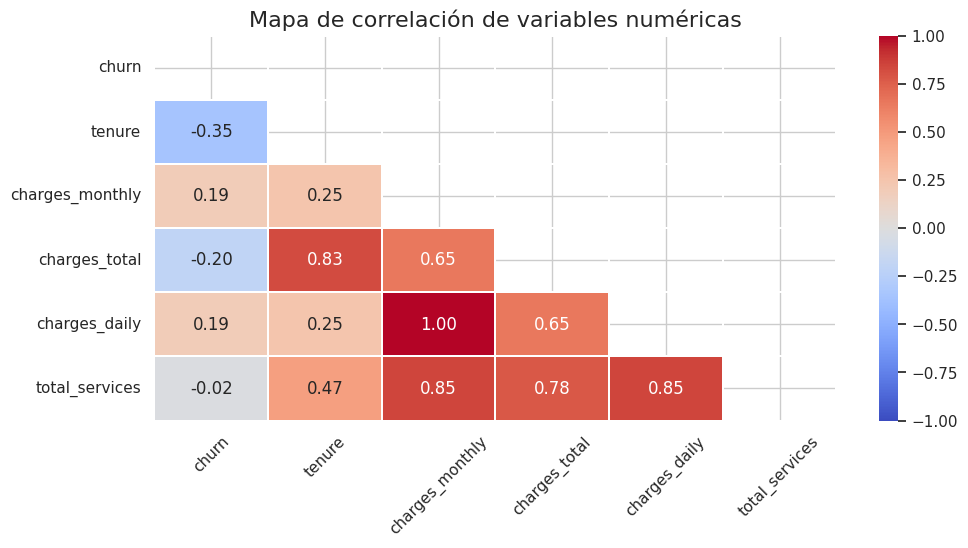

In [37]:
# Crear matriz de correlación entre variables numéricas
matriz_corr = datos_corr.corr(numeric_only=True)

# Crear mapa de correlación entre variables numéricas

mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 5))
ax = sns.heatmap(data=matriz_corr, mask=mascara, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidths=0.1)

ax.set_title('Mapa de correlación de variables numéricas', fontsize=16)
plt.xticks(rotation=45)

plt.show()

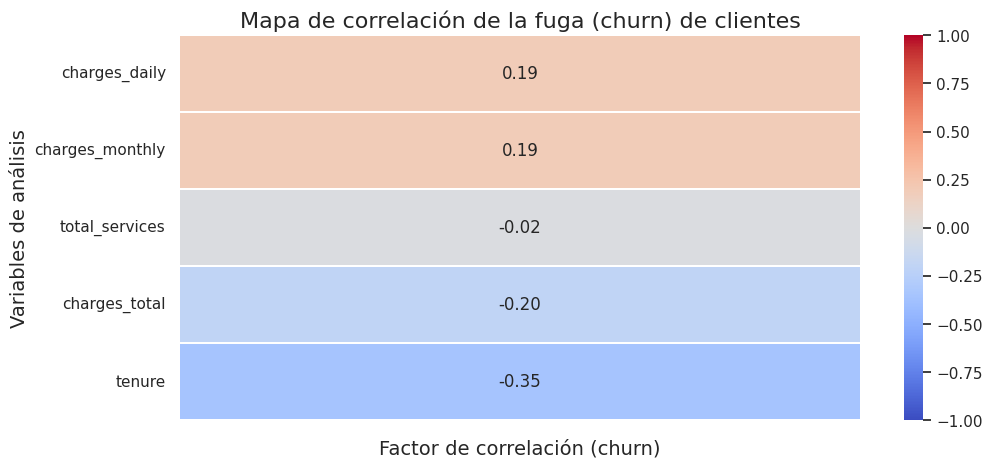

In [38]:
# Crear matriz de correlación de la columna 'churn'
corr_churn = datos_corr.corr(numeric_only=True)[['churn']].drop('churn').sort_values(by='churn', ascending=False)

# Crear mapa de correlación de la columna 'churn'
fig, ax = plt.subplots(figsize=(11, 5))
ax = sns.heatmap(data=corr_churn, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidths=0.1)

ax.set_title('Mapa de correlación de la fuga (churn) de clientes', fontsize=16)
ax.set_xlabel('Factor de correlación (churn)', fontsize=14)
ax.set_xticklabels('')
ax.set_ylabel('Variables de análisis', fontsize=14)

plt.show()

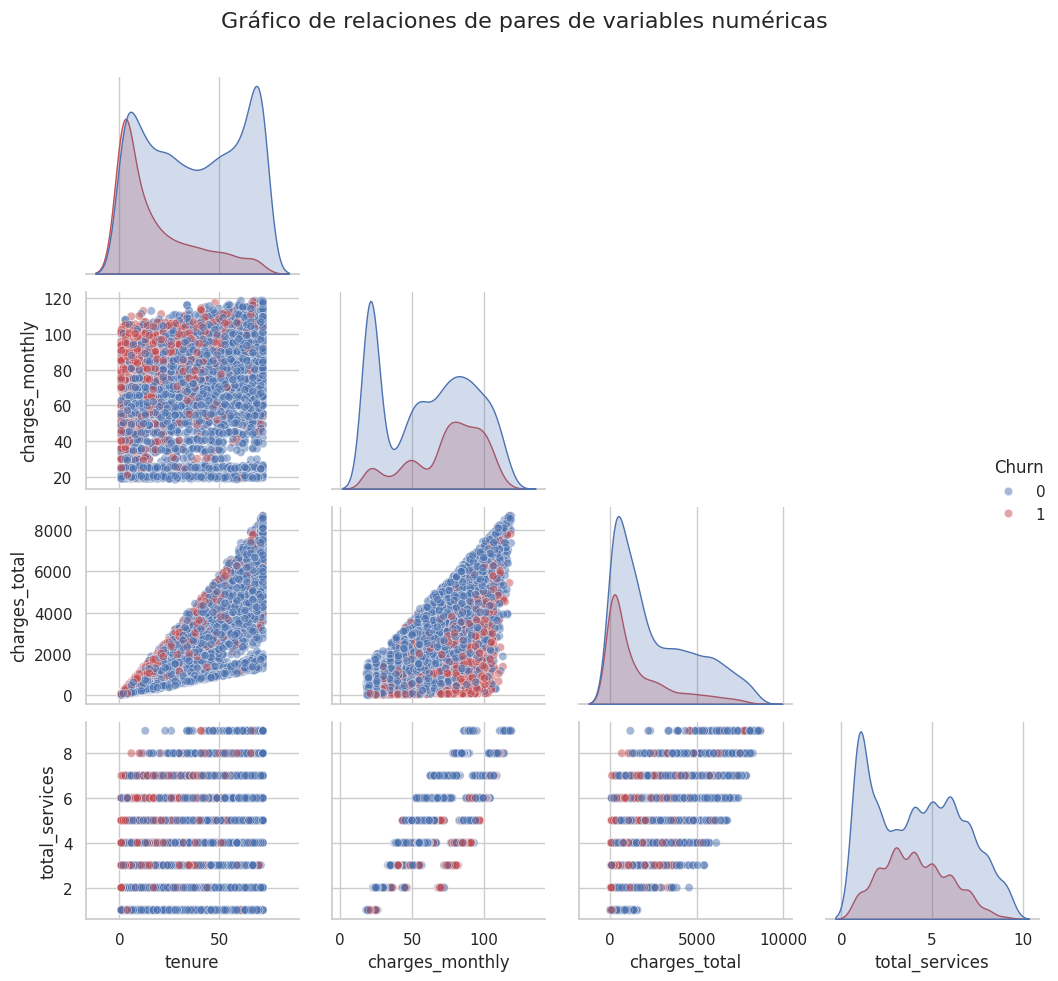

In [39]:
# Graficar relaciones de pares entre variables numéricas
col_numericas = ['tenure', 'charges_monthly', 'charges_total', 'total_services']

chart = sns.pairplot(datos_corr, vars=col_numericas, hue='churn', corner=True, diag_kind='kde', plot_kws={'alpha': 0.5})
chart.fig.suptitle('Gráfico de relaciones de pares de variables numéricas', fontsize=16)
chart._legend.set_title('Churn')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# 📄 Informe final

## Introducción

El propósito del presente estudio es analizar datos de la empresa Telecom X en el contexto del proyecto "Churn de Clientes". La empresa enfrenta una alta tasa de cancelaciones y necesita identificar los factores críticos que llevan a la pérdida de clientes.

Se recopilarán, procesarán y analizarán los datos con el fin de extraer información de valor y generar hallazgos accionables que permitan al equipo de Data Science de la empresa construir modelos predictivos y desarrollar estrategias que permitan mejorar la retención y reducir la fuga de clientes.

## Limpieza y tratamiento de datos

El proceso de preparación de los datos para el análisis se divide en las siguientes etapas:

* Importación:
  - Importación de los datos mediante la biblioteca Pandas.
  - Visualización general de los datos.

* Limpieza:
  - Comprobación de inconsistencias en los datos.
  - Transformación de variables al tipo de dato adecuado.
  - Eliminación de registros con valores vacíos de la variable `Churn`.
  - Verificación de la existencia de valores nulos.
  - Verificación de la existencia de registros duplicados.

* Procesamiento:
  - Creación de variables adicionales.
  - Estandarización de variables categóricas.
  - Cambio de nombre de las columnas.

## Análisis exploratorio de datos

### Distribución de la fuga de clientes

Dado que la disminución de la fuga de clientes es el principal objetivo, se comienza analizando la distribución de la variable `churn`.

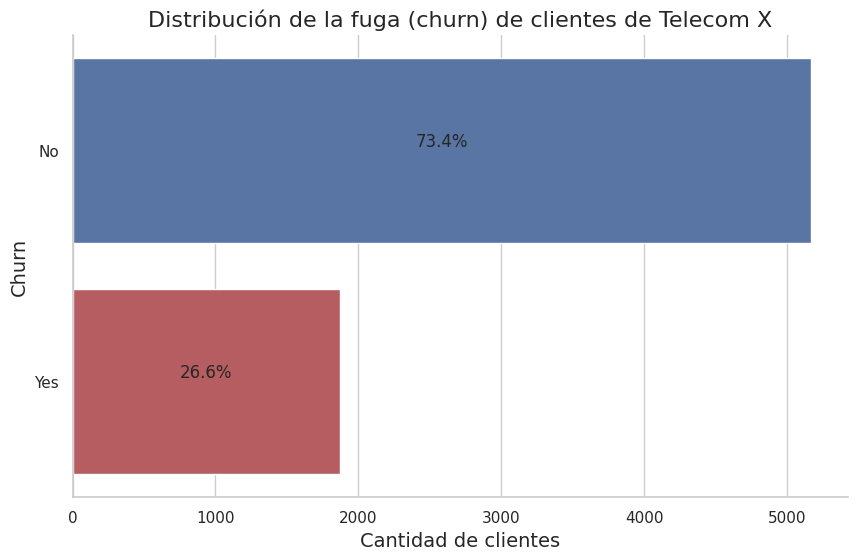

Se evidencia que el 26.6% de los clientes se han fugado. Esta cifra indica una base de datos desbalanceada, pues la retención predomina (73.4%), pero la tasa de fuga es significativa. Es necesario identificar qué variables impulsan este porcentaje de fuga.

### Distribución de la fuga de clientes por variables categóricas

Con el fin de analizar cómo se comporta la fuga de clientes de acuerdo con las variables categóricas e identificar factores críticos, se presentan todos los gráficos de distribución por variables categóricas.

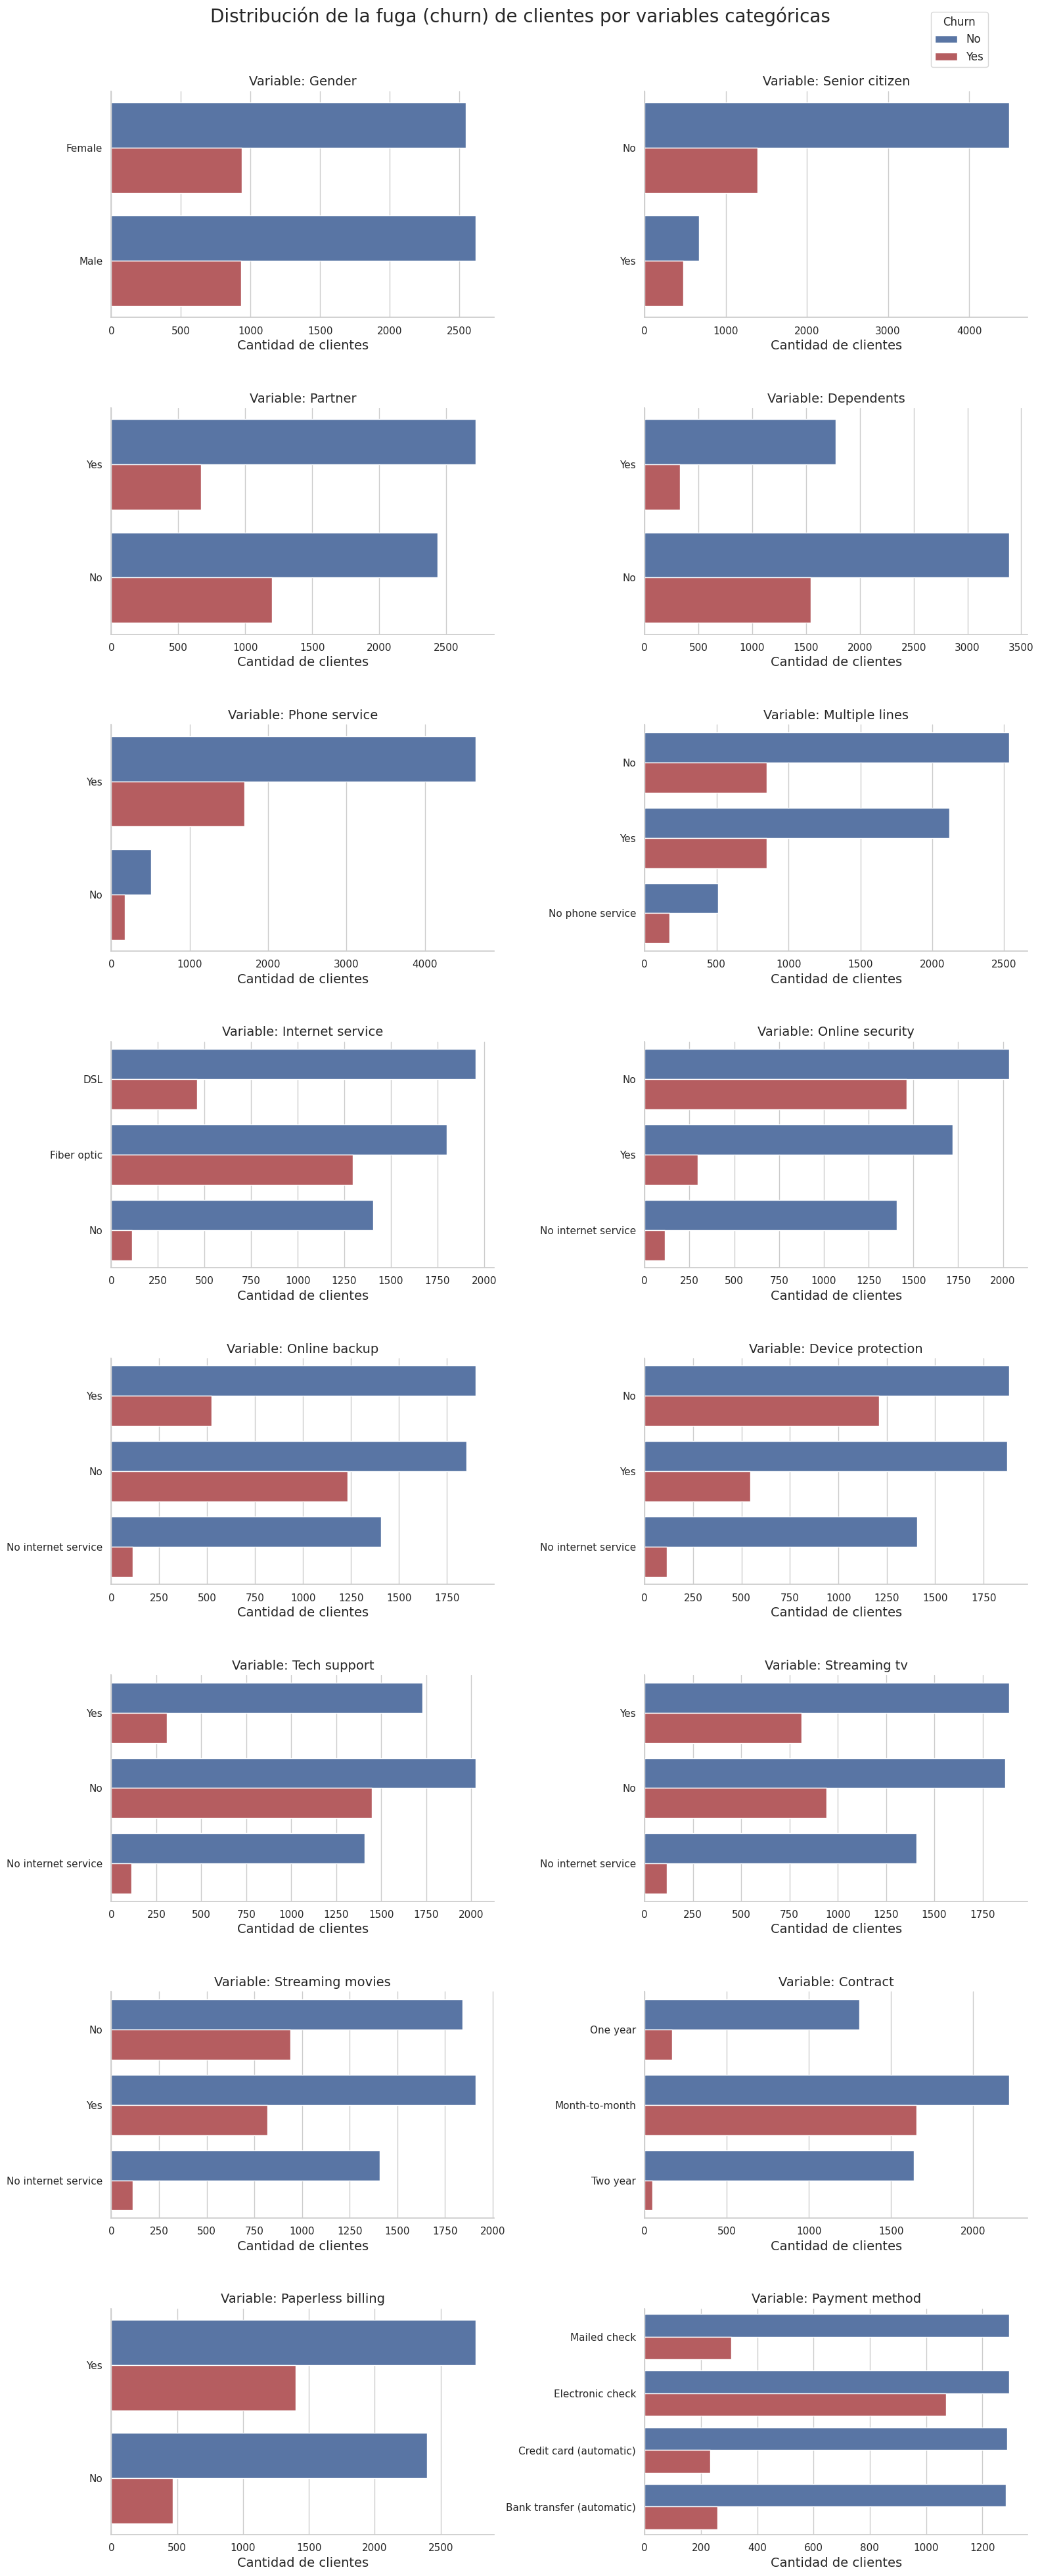

El análisis visual permite identificar que la fuga de clientes se dispara en variables específicas:

* Tipo de internet: Los clientes que tienen servicio de internet por fibra óptica tienen una tasa de fuga muy alta en comparación con usuarios de DSL.

* Servicios adicionales: La ausencia de servicios de internet adicionales como seguridad online, backup online, protección de dispositivo y soporte técnico, aumenta la probabilidad de abandono de los clientes.

* Tipo de contrato: Los clientes que tienen un contrato mes a mes representan una vulnerabilidad crítica. La fuga es mínima en los clientes con contrato a uno o dos años.

* Medio de pago: Los clientes que utilizan el cheque electrónico como método de pago son más propensos a abandonar la empresa.

### Distribución de la fuga de clientes por variables numéricas

Asimismo, es relevante analizar el comportamiento de la fuga de clientes de acuerdo con las variables numéricas, ya que puede revelar información de valor que complemente lo anterior.

Distribución de la fuga de clientes según los meses de contrato:

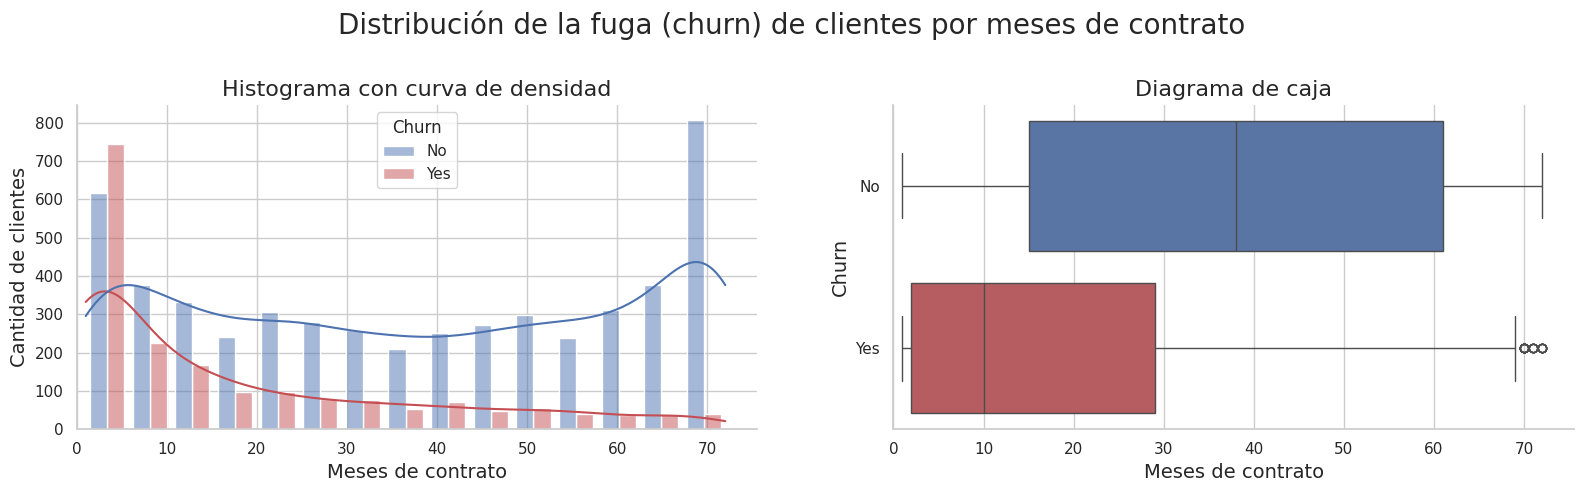

El histograma revela que la fase crítica de deserción durante los primeros 10 meses. El diagrama de caja confirma que el 50% de los clientes que se han fugado lo han hecho teniendo el servicio por un período menor o igual a 10 meses.

Esto tiene sentido al relacionarlo con el tipo de contrato, pues los clientes que tienen un contrato a uno o dos años no pueden abandonar antes de los 12 meses. Es decir, Dicho 50% de clientes que se fugan a lo más a los 10 meses, son todos con un tipo de contrato mensual, validando la vulnerabilidad de los contratos con esta modalidad.

Distribución de la fuga de clientes según el cargo mensual:

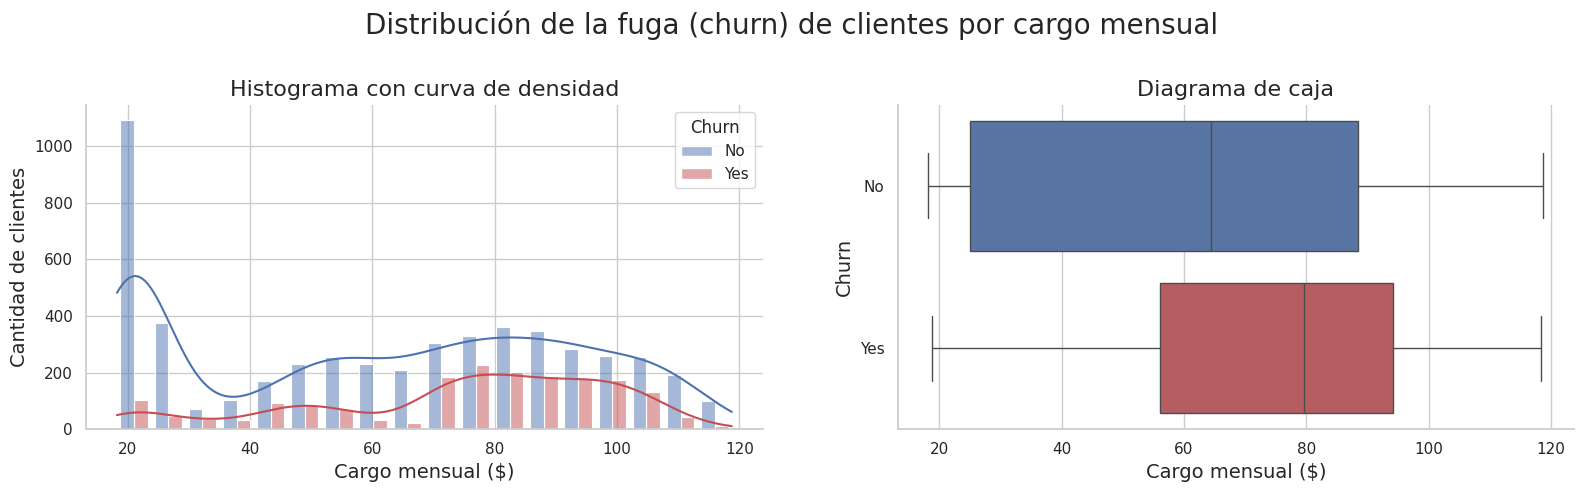

El histograma indica que la mayor cantidad de clientes que ha abandonado tiene un cargo mensual aproximado entre 70 USD y 100 USD. También se nota que los clientes que tienen un cargo mensual mínimo (~20 USD), tienen una alta probabilidad de mantenerse.

Por su parte, el diagrama de caja revela que los clientes que abandonan se concentran en un rango mayor de cargo mensual con respecto a los que se mantienen, mostrando que la sensibilidad al precio o la relación costo-beneficio es un factor importante en cuanto a la retención del cliente.

Distribución de la fuga de clientes según el cargo total:

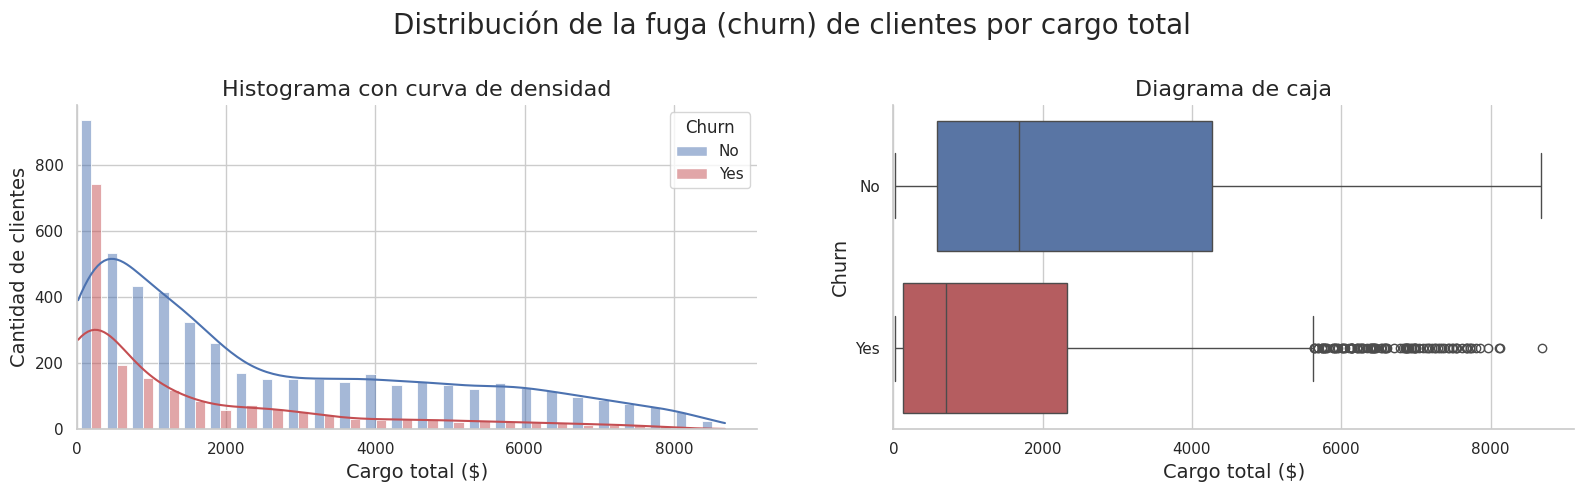

En ambos gráficos se observa que los clientes que se han fugado tienden a ser los que tienen un cargo total bajo (clientes nuevos). Sin embargo, el diagrama de caja permite visualizar que hay un número no menor de clientes atípicos que se han fugado con un cargo total muy elevado (clientes antiguos).

Estos clientes antiguos representan una pérdida financiera importante para la empresa, pues se han fugado tras una larga relación e inversión en los servicios de la empresa.

Distribución de la fuga de clientes según los servicios contratados:

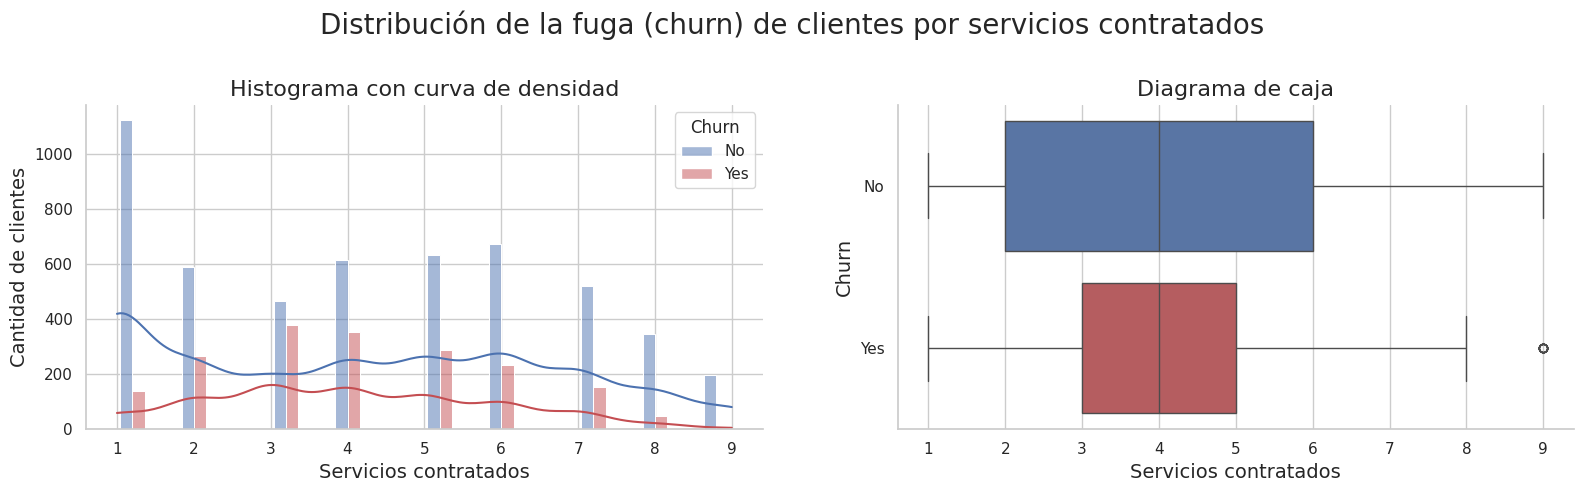

El histograma permite apreciar que los clientes que solo tienen un servicio contratado han sido los más leales, mientras que el diagrama de caja indica que la mitad de los clientes que se han fugado lo han hecho teniendo entre 3 y 5 servicios contratados.

Se torna importante evaluar si la capacidad de fidelización de los servicios adicionales es la esperada o si está bien implementada.

### Análisis de correlación

Para comparar la magnitud de las relaciones entre las variables numéricas, se presenta un mapa de correlación general.

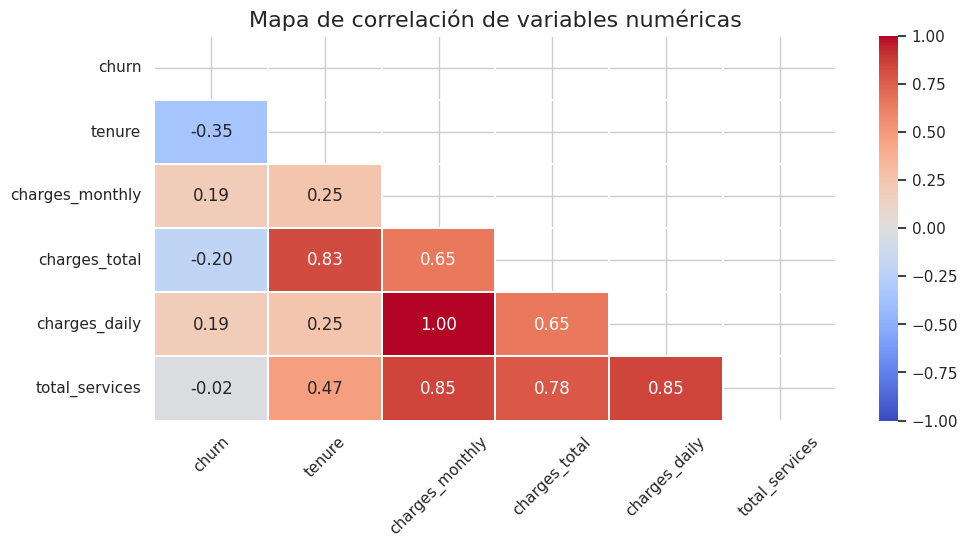

Se identifican las siguientes dinámicas entre variables:

* Relaciones directas fuertes: Como es de esperar, la antigüedad (tenure) y el cargo mensual tienen una relación directa fuerte con el cargo total. A mayor tiempo o mayor mensualidad, mayor es el valor acumulado del cliente.

* Redundancia crítica: El cargo diario y el cargo mensual tienen una correlación de 1.00. Presentan multicolinealidad perfecta ya que representan la misma información, por lo que una de ellas es redundante.

* Crecimiento del portafolio de productos: Hay una relación directa moderada entre la antigüedad y la cantidad de servicios, sugiriendo que los clientes contratan más servicios a medida que su relación con la empresa se consolida.

Específicamente, se analiza la relación de las variables con respecto a la fuga de clientes:

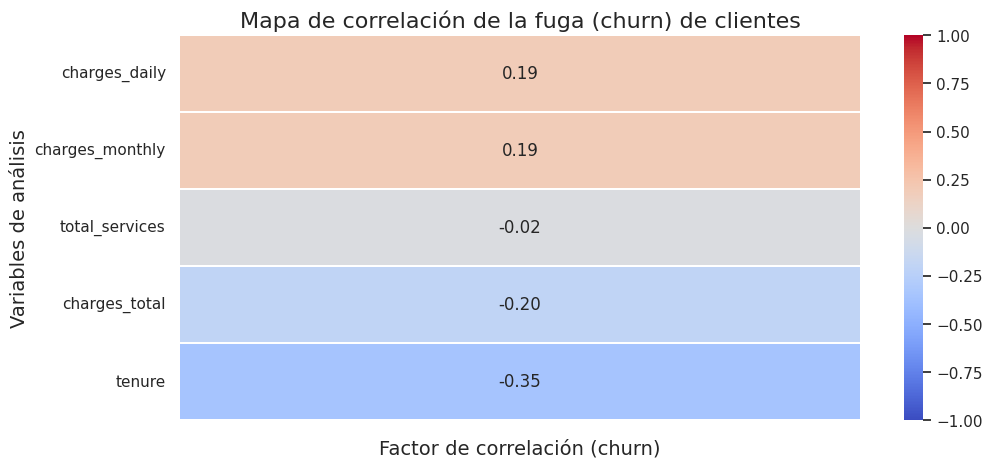

Se aprecian las siguientes relaciones:

* Factor de retención: La antigüedad es la variable que más influye en la retención de clientes (-0.35). Se valida que a mayor permanencia en la empresa, menor es la probabilidad de fuga.

* Divergencia entre cargos: Mientras que un mayor cargo mensual aumenta el riesgo de fuga (0.19), un mayor cargo total favorece la retención (-0.20). El cargo actual actúa como un indicador indirecto de la lealtad y tiempo de permanencia (tenure) del cliente.

* Indiferencia en la cantidad de servicios: La cantidad de servicios contratados no influye en la retención de clientes (-0.02). Esto concuerda con la distribución de la fuga según los servicios contratados, lo que refuerza la necesidad de una evaluación de los servicios adicionales en cuanto a su capacidad para mantener satisfechos a los clientes y favorecer su retención.

Finalmente, se genera un gráfico de relaciones de pares permite cruzar estas variables filtrando por la fuga de clientes.

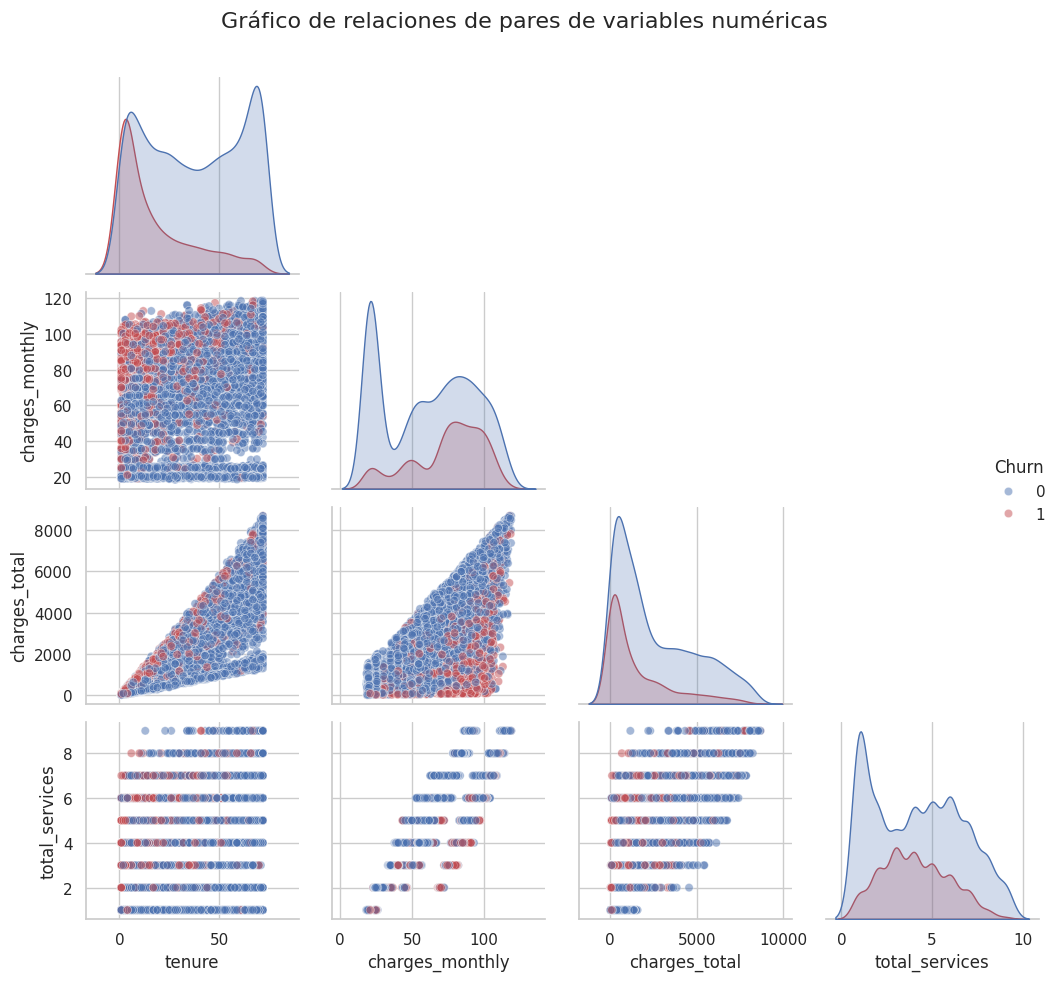

Hallazgos relevantes:

* Zona de riesgo: El gráfico entre Cargo mensual vs Antigüedad muestra una alta concentración de fugas en clientes nuevos con pagos mensuales altos.

* Ciclo de vida: La relación Cargo total vs Cargo mensual revela que las fugas ocurren mayoritariamente de forma temprana, antes de que el costo total logre incrementarse, especialmente cuando el cargo mensual es elevado.

## Conclusiones y hallazgos clave

Tras el análisis de exploratorio de datos, se han revelado factores críticos y patrones determinantes que impulsan la fuga clientes.

Los hallazgos clave se resumen en los siguientes puntos:

* Perfil de riesgo: La fuga se concentra drásticamente en los usuarios de internet de fibra óptica, clientes con escasa adopción de servicios adicionales, aquellos bajo la modalidad de contrato mensual, y quienes utilizan el cheque electrónico como medio de pago.

* La barrera de los 10 meses: Existe una etapa crítica de abandono temprano. Los clientes tienden a fugarse dentro de sus primeros 10 meses de relación con la empresa. Este fenómeno se intensifica cuando los cargos mensuales son elevados.

* Sensibilidad al precio: A mayor cargo mensual, aumenta la probabilidad de abandono. Por el contrario, los clientes con cargos mínimos muestran niveles superiores de lealtad.

* Fuga de clientes de alto valor: Un segmento de clientes antiguos deciden abandonar a pesar de su relación de largo plazo con la empresa, lo que representa una pérdida financiera relevante para la empresa dado el valor acumulado que estos clientes aportan.

* Ineficacia del upselling: A pesar de que la antigüedad fomenta la contratación de más servicios adicionales, el análisis demuestra que no garantizan la retención. Los servicios no logran fidelizar a los clientes.

* Antigüedad como ancla: La antigüedad es la variable más influyente en la retención. Superar el umbral de los 10 meses reduce drásticamente la probabilidad de fuga.

## Recomendaciones

Las sugerencias estratégicas para Telecom X de acuerdo con la información extraída son:

* Auditoría del servicio de internet de fibra óptica: Revisar las características de este servicio (precio, estabilidad y velocidad), pues su alta tasa de fuga sugiere una brecha entre la expectativa del cliente y la realidad del servicio.

* Estrategia de retención temprana: Ofrecer promociones para clientes nuevos con el fin de aumentar la probabilidad de permanencia durante los primeros 10 meses. Por ejemplo, ofrecer descuentos durante el primer semestre o un valor agregado por migrar de un contrato mensual a uno por uno o dos años.

* Incentivo al pago automático: Fomentar la migración hacia métodos de pago automáticos (con cuenta o tarjeta) mediante bonificaciones, con el fin de disminuir la probabilidad de fuga asociada a los pagos manuales como el cheque electrónico.

* Reevaluación de servicios adicionales: Analizar la relación precio-calidad de los servicios ofrecidos, especialmente en el caso de los adicionales, para asegurar que actúen como verdaderos factores de fidelización.

* Estrategia de retención para clientes antiguos: Crear un sistema de alertas para identificar cambios de comportamiento de estos clientes, y diseñar soluciones personalizadas para que su relación con la empresa sea sostenible a largo plazo, evitando pérdidas financieras de alto impacto.